# Lab 2 — Online Shoppers Purchasing Intention
## Introduction to Machine Learning — Practical Lab 2
### Entrepreneurship in Africa — Startup Deployment Scenario

**Auteur :** _[Votre nom]_  
**Date :** Février 2026  
**Dataset :** [UCI Online Shoppers Purchasing Intention](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset)

---

## 1. Contexte

De nombreuses startups digitales en Afrique opèrent dans des environnements où les données sont limitées, les infrastructures contraintes, et les décisions de déploiement doivent équilibrer performance et efficacité.

Dans ce TP, nous allons :
1. Construire et comparer des modèles ML (Régression Logistique, Gradient Boosting, Réseau de Neurones)
2. Appliquer un protocole expérimental rigoureux (train/validation/test)
3. Compresser les modèles (pruning et quantization) pour un déploiement en contexte startup
4. Évaluer les compromis performance / efficacité / faisabilité

**Seed aléatoire :** `random_state=42` pour la reproductibilité.

---
## 2. Importation des librairies

In [1]:
# ----- Librairies de base -----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
import sys
import pickle
import copy

# ----- Scikit-learn : prétraitement -----
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

# ----- Scikit-learn : modèles -----
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# ----- Scikit-learn : évaluation -----
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)

# ----- PyTorch : réseau de neurones -----
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ----- Configuration visuelle -----
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
warnings.filterwarnings('ignore')

# ----- Reproductibilité -----
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python {sys.version}")
print(f"NumPy {np.__version__}")
print(f"Pandas {pd.__version__}")
print(f"Scikit-learn {__import__('sklearn').__version__}")
print(f"PyTorch {torch.__version__}")

Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
NumPy 2.0.0
Pandas 2.2.3
Scikit-learn 1.6.1
PyTorch 2.7.1+cpu


---
## 3. Chargement et exploration des données

In [2]:
# Chargement du dataset
df = pd.read_csv('online_shoppers_intention.csv')

print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nPremières lignes :")
df.head()

Dimensions du dataset : 12330 lignes × 18 colonnes

Premières lignes :


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Informations sur les types de données et valeurs manquantes
print("=" * 60)
print("TYPES DE DONNÉES ET VALEURS MANQUANTES")
print("=" * 60)
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Non-Null': df.count(),
    'Null': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique': df.nunique()
})
print(info_df)
print(f"\nTotal missing values : {df.isnull().sum().sum()}")

TYPES DE DONNÉES ET VALEURS MANQUANTES
                            Type  Non-Null  Null  Null %  Unique
Administrative             int64     12330     0     0.0      27
Administrative_Duration  float64     12330     0     0.0    3335
Informational              int64     12330     0     0.0      17
Informational_Duration   float64     12330     0     0.0    1258
ProductRelated             int64     12330     0     0.0     311
ProductRelated_Duration  float64     12330     0     0.0    9551
BounceRates              float64     12330     0     0.0    1872
ExitRates                float64     12330     0     0.0    4777
PageValues               float64     12330     0     0.0    2704
SpecialDay               float64     12330     0     0.0       6
Month                     object     12330     0     0.0      10
OperatingSystems           int64     12330     0     0.0       8
Browser                    int64     12330     0     0.0      13
Region                     int64     12330     0   

In [4]:
# Statistiques descriptives pour les variables numériques
print("=" * 60)
print("STATISTIQUES DESCRIPTIVES — VARIABLES NUMÉRIQUES")
print("=" * 60)
df.describe().T

STATISTIQUES DESCRIPTIVES — VARIABLES NUMÉRIQUES


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [5]:
# Statistiques pour les variables catégorielles
print("=" * 60)
print("VARIABLES CATÉGORIELLES")
print("=" * 60)
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Colonnes catégorielles : {cat_cols}\n")
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

VARIABLES CATÉGORIELLES
Colonnes catégorielles : ['Month', 'VisitorType', 'Weekend', 'Revenue']

--- Month ---
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

--- VisitorType ---
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

--- Weekend ---
Weekend
False    9462
True     2868
Name: count, dtype: int64

--- Revenue ---
Revenue
False    10422
True      1908
Name: count, dtype: int64



### 3.1 Distribution de la variable cible

**Choix justifié :** La variable cible est `Revenue` (TRUE/FALSE). Il est crucial d'examiner le déséquilibre de classes car il impacte directement le choix des métriques d'évaluation et la stratégie d'entraînement.

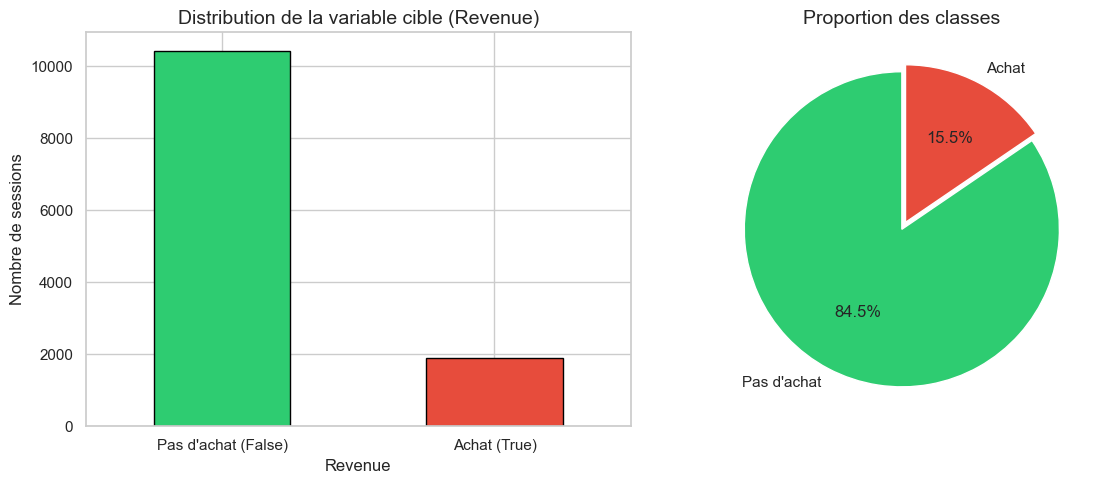


Classe majoritaire (False) : 10422 (84.5%)
Classe minoritaire (True)  : 1908 (15.5%)
Ratio de déséquilibre      : 1:5.5


In [6]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Comptage
target_counts = df['Revenue'].value_counts()
colors = ['#2ecc71', '#e74c3c']
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribution de la variable cible (Revenue)', fontsize=14)
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Nombre de sessions')
axes[0].set_xticklabels(['Pas d\'achat (False)', 'Achat (True)'], rotation=0)

# Pourcentages
target_pct = df['Revenue'].value_counts(normalize=True) * 100
axes[1].pie(target_pct, labels=['Pas d\'achat', 'Achat'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05))
axes[1].set_title('Proportion des classes', fontsize=14)

plt.tight_layout()
plt.show()

print(f"\nClasse majoritaire (False) : {target_counts[False]} ({target_pct[False]:.1f}%)")
print(f"Classe minoritaire (True)  : {target_counts[True]} ({target_pct[True]:.1f}%)")
print(f"Ratio de déséquilibre      : 1:{target_counts[False]/target_counts[True]:.1f}")

**Observation :** Le dataset est déséquilibré (~85% False vs ~15% True). Cela justifie l'utilisation de métriques comme le F1-score, la précision et le rappel plutôt que l'accuracy seule.

### 3.2 Distribution des variables numériques — Analyse de l'asymétrie (skewness)

In [7]:
# Identification des variables numériques
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variables numériques ({len(num_cols)}) : {num_cols}\n")

# Calcul du skewness (asymétrie)
skew_values = df[num_cols].skew().sort_values(ascending=False)
print("=" * 50)
print("SKEWNESS (ASYMÉTRIE) DES VARIABLES NUMÉRIQUES")
print("=" * 50)
print(skew_values)
print(f"\nVariables fortement asymétriques (|skew| > 2) : {(skew_values.abs() > 2).sum()}")

Variables numériques (14) : ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

SKEWNESS (ASYMÉTRIE) DES VARIABLES NUMÉRIQUES
Informational_Duration     7.579185
ProductRelated_Duration    7.263228
PageValues                 6.382964
Administrative_Duration    5.615719
ProductRelated             4.341516
Informational              4.036464
SpecialDay                 3.302667
Browser                    3.242350
BounceRates                2.947855
ExitRates                  2.148789
OperatingSystems           2.066285
TrafficType                1.962987
Administrative             1.960357
Region                     0.983549
dtype: float64

Variables fortement asymétriques (|skew| > 2) : 11


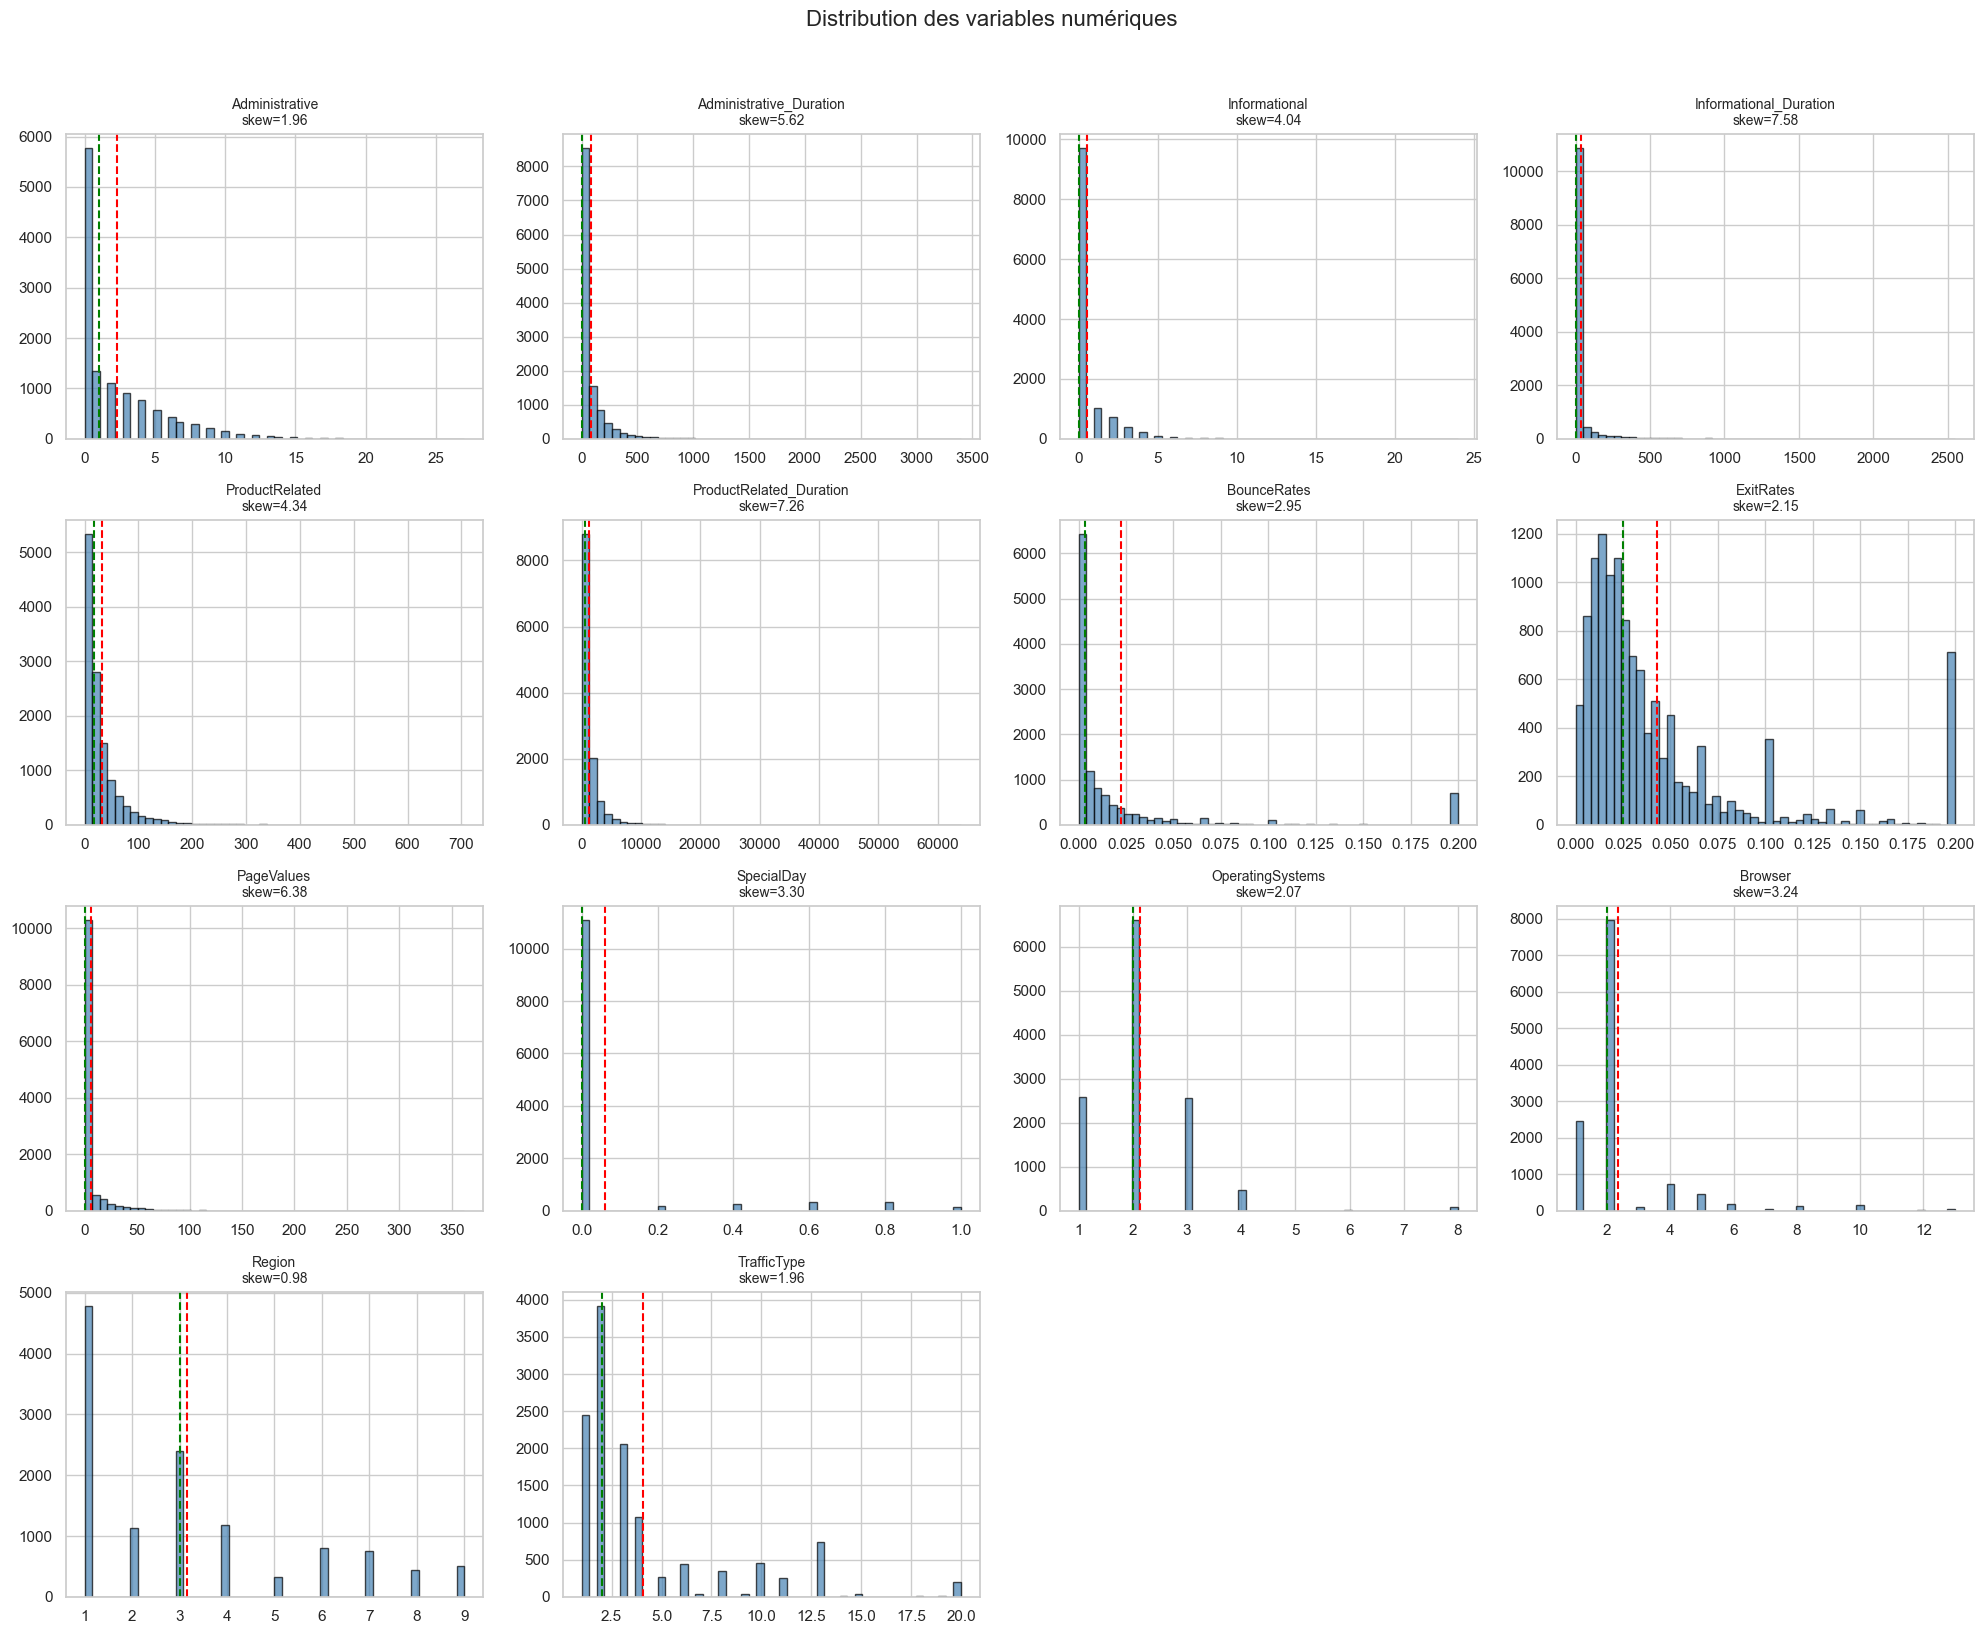

In [8]:
# Visualisation des distributions des variables numériques
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols[:16]):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}\nskew={df[col].skew():.2f}', fontsize=10)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Moyenne')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label='Médiane')

# Masquer les axes inutilisés
for j in range(len(num_cols), 16):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables numériques', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Observations clés :**
- Les variables de durée (`Administrative_Duration`, `Informational_Duration`, `ProductRelated_Duration`) et `PageValues` sont **fortement asymétriques** (skew élevé).
- `BounceRates` et `ExitRates` montrent aussi une distribution concentrée à gauche.
- Ces distributions asymétriques peuvent affecter les modèles linéaires → **transformation log justifiée** pour réduire l'asymétrie.

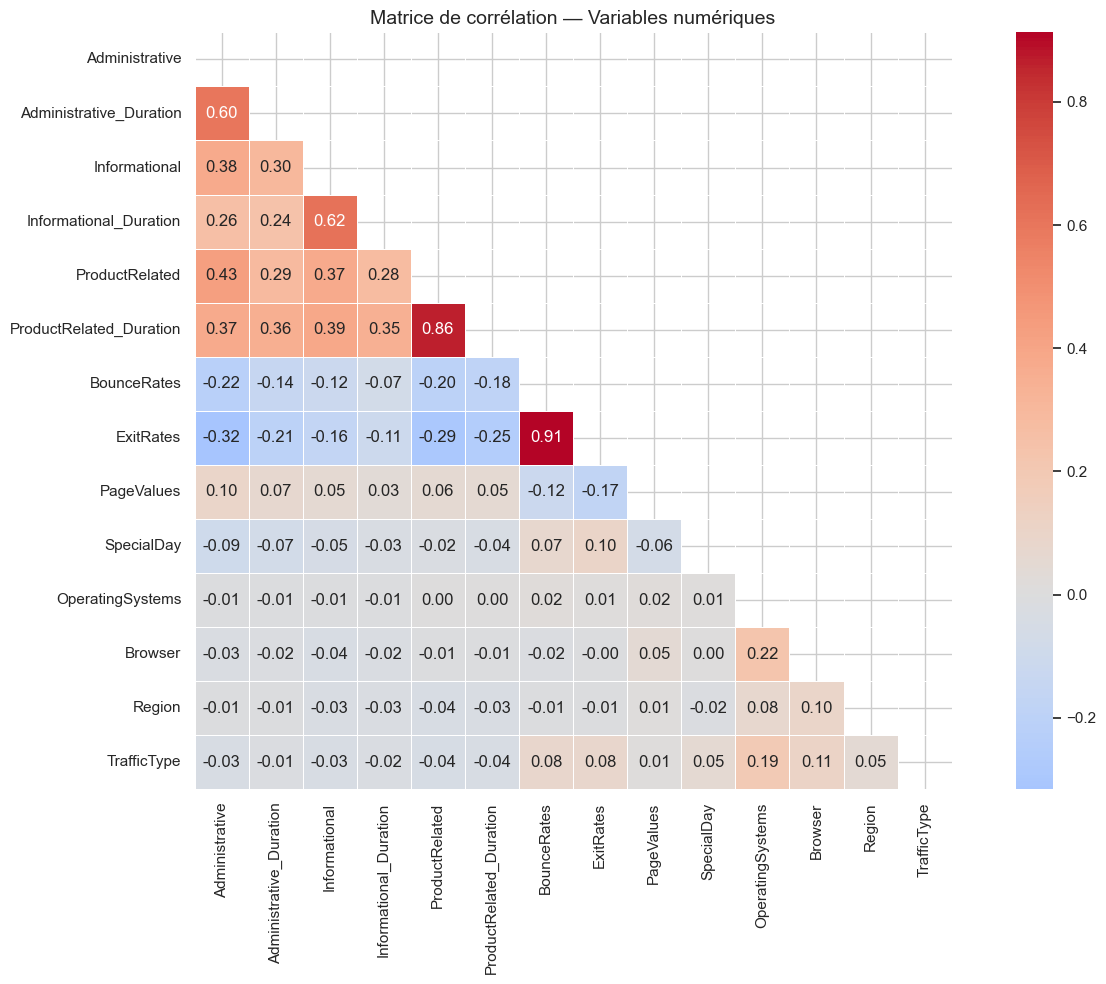

In [9]:
# Matrice de corrélation
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matrice de corrélation — Variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Définition du problème et choix des métriques

### Problème
Classification binaire : prédire si une session aboutira à un achat (`Revenue = True`).

### Choix des métriques

| Métrique | Justification |
|----------|---------------|
| **F1-score** | Équilibre entre précision et rappel — essentiel pour les classes déséquilibrées |
| **Precision** | Coût des faux positifs (campagnes marketing ciblant les mauvais utilisateurs) |
| **Recall** | Coût des faux négatifs (manquer des acheteurs potentiels) |
| **AUC-ROC** | Évalue la capacité de discrimination indépendamment du seuil |
| **Accuracy** | Reportée mais NON utilisée comme critère principal (trompeuse avec classe déséquilibrée) |

Dans un contexte startup e-commerce, **le rappel est important** (ne pas manquer d'acheteurs), mais **la précision aussi** pour éviter de gaspiller des ressources marketing. Le F1-score est donc notre métrique principale.

---
## 5. Préparation des données

### 5.1 Protocole expérimental

**Split recommandé :** 70% Train / 15% Validation / 15% Test  
**Contraintes :**
- Pas de fuite de données (data leakage) entre les splits
- Le prétraitement est **fit sur les données de training uniquement** puis transformé sur val/test
- Le test set n'est utilisé qu'une seule fois pour l'évaluation finale
- `stratify=y` pour maintenir la distribution des classes dans chaque split

In [10]:
# ========================================
# 5.1 — Séparation features / target
# ========================================

# Conversion de la cible en entier (True → 1, False → 0)
df['Revenue'] = df['Revenue'].astype(int)

# Conversion de Weekend en entier également
df['Weekend'] = df['Weekend'].astype(int)

X = df.drop('Revenue', axis=1)
y = df['Revenue']

print(f"Features : {X.shape}")
print(f"Target   : {y.shape}")
print(f"\nDistribution cible : \n{y.value_counts()}")

Features : (12330, 17)
Target   : (12330,)

Distribution cible : 
Revenue
0    10422
1     1908
Name: count, dtype: int64


In [11]:
# ========================================
# 5.2 — Split : 70% Train / 15% Val / 15% Test
# ========================================
# Étape 1 : 70% train / 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Étape 2 : 50/50 du temp → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("=" * 50)
print("RÉPARTITION DES DONNÉES")
print("=" * 50)
for name, X_split, y_split in [('Train', X_train, y_train), 
                                 ('Validation', X_val, y_val), 
                                 ('Test', X_test, y_test)]:
    print(f"{name:12s} : {len(X_split):5d} ({len(X_split)/len(X)*100:.1f}%) | "
          f"Class 0: {(y_split==0).sum()} ({(y_split==0).mean()*100:.1f}%) | "
          f"Class 1: {(y_split==1).sum()} ({(y_split==1).mean()*100:.1f}%)")

RÉPARTITION DES DONNÉES
Train        :  8631 (70.0%) | Class 0: 7295 (84.5%) | Class 1: 1336 (15.5%)
Validation   :  1849 (15.0%) | Class 0: 1563 (84.5%) | Class 1: 286 (15.5%)
Test         :  1850 (15.0%) | Class 0: 1564 (84.5%) | Class 1: 286 (15.5%)


### 5.3 Encodage des variables catégorielles

**Stratégie choisie : Encodage ordinal + One-Hot selon le type de variable**

| Variable | Type | Stratégie | Justification |
|----------|------|-----------|---------------|
| `Month` | Nominale (10 catégories) | One-Hot Encoding | Pas d'ordre naturel entre les mois dans ce contexte |
| `VisitorType` | Nominale (3 catégories) | One-Hot Encoding | Catégories indépendantes |
| `Weekend` | Binaire | Déjà converti en 0/1 | Variable booléenne |

**Pourquoi One-Hot plutôt que Label Encoding ?**  
Le Label Encoding imposerait un ordre artificiel entre les catégories (ex: Feb=0, Mar=1), ce que les modèles linéaires interpréteraient comme une relation d'ordinalité qui n'existe pas.

In [12]:
# ========================================
# 5.3 — Encodage catégoriel (One-Hot)
# ========================================

# Identification des colonnes catégorielles restantes
cat_features = ['Month', 'VisitorType']
print(f"Variables à encoder : {cat_features}")

# Application du One-Hot Encoding
# On l'applique de manière identique sur train, val, et test
# en utilisant pd.get_dummies avec les mêmes catégories
X_train_encoded = pd.get_dummies(X_train, columns=cat_features, drop_first=False)
X_val_encoded = pd.get_dummies(X_val, columns=cat_features, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, columns=cat_features, drop_first=False)

# Aligner les colonnes entre train, val et test (au cas où certaines catégories
# n'apparaissent pas dans le val/test)
all_columns = X_train_encoded.columns
X_val_encoded = X_val_encoded.reindex(columns=all_columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=all_columns, fill_value=0)

print(f"\nDimensions après encodage :")
print(f"  Train      : {X_train_encoded.shape}")
print(f"  Validation : {X_val_encoded.shape}")
print(f"  Test       : {X_test_encoded.shape}")
print(f"\nNouvelles colonnes ({len(all_columns)}) :")
print(list(all_columns))

Variables à encoder : ['Month', 'VisitorType']

Dimensions après encodage :
  Train      : (8631, 28)
  Validation : (1849, 28)
  Test       : (1850, 28)

Nouvelles colonnes (28) :
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_New_Visitor', 'VisitorType_Other', 'VisitorType_Returning_Visitor']


### 5.4 Transformation logarithmique des variables asymétriques

**Justification :**  
Les variables de durée et `PageValues` ont une forte asymétrie positive (skew >> 2). La transformation `log(1 + x)` :
- Réduit l'influence des valeurs extrêmes
- Rend la distribution plus symétrique
- Améliore les performances des modèles linéaires (hypothèse de normalité)
- Préserve les zéros grâce au `+1`

**Important :** La transformation est appliquée de la même manière sur train, val et test (pas de fuite de données car c'est une transformation déterministe sans paramètres à fit).

In [13]:
# ========================================
# 5.4 — Transformation log(1+x) sur variables asymétriques
# ========================================

# Variables avec skewness élevée à transformer
skewed_cols = ['Administrative_Duration', 'Informational_Duration',
               'ProductRelated_Duration', 'PageValues',
               'ProductRelated', 'Administrative', 'Informational']

# Vérifier lesquelles existent dans nos données encodées
skewed_cols = [c for c in skewed_cols if c in X_train_encoded.columns]

print("Skewness AVANT transformation log :")
for col in skewed_cols:
    print(f"  {col:35s} : {X_train_encoded[col].skew():.3f}")

# Application de log(1+x)
for col in skewed_cols:
    X_train_encoded[col] = np.log1p(X_train_encoded[col])
    X_val_encoded[col] = np.log1p(X_val_encoded[col])
    X_test_encoded[col] = np.log1p(X_test_encoded[col])

print("\nSkewness APRÈS transformation log :")
for col in skewed_cols:
    print(f"  {col:35s} : {X_train_encoded[col].skew():.3f}")

Skewness AVANT transformation log :
  Administrative_Duration             : 5.778
  Informational_Duration              : 7.866
  ProductRelated_Duration             : 8.506
  PageValues                          : 6.171
  ProductRelated                      : 4.424
  Administrative                      : 1.977
  Informational                       : 4.207

Skewness APRÈS transformation log :
  Administrative_Duration             : 0.253
  Informational_Duration              : 1.918
  ProductRelated_Duration             : -1.422
  PageValues                          : 1.804
  ProductRelated                      : -0.057
  Administrative                      : 0.562
  Informational                       : 2.030


### 5.5 Standardisation (StandardScaler)

**Justification :**
- La régression logistique et les réseaux de neurones sont sensibles à l'échelle des features
- Le StandardScaler centre (moyenne=0) et réduit (std=1) les variables
- **Fit sur train uniquement** → transform sur val et test (prévention du data leakage)

In [14]:
# ========================================
# 5.5 — Standardisation (fit sur train uniquement)
# ========================================

scaler = StandardScaler()

# Colonnes numériques à standardiser (exclure les One-Hot qui sont déjà 0/1)
num_features = ['Administrative', 'Administrative_Duration', 'Informational',
                'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
                'OperatingSystems', 'Browser', 'Region', 'TrafficType']

# Vérifier lesquelles existent
num_features = [c for c in num_features if c in X_train_encoded.columns]

# FIT sur train, TRANSFORM sur train/val/test
X_train_encoded[num_features] = scaler.fit_transform(X_train_encoded[num_features])
X_val_encoded[num_features] = scaler.transform(X_val_encoded[num_features])
X_test_encoded[num_features] = scaler.transform(X_test_encoded[num_features])

print("Standardisation appliquée (fit sur train, transform sur val/test)")
print(f"\nMoyenne des features de train (devrait être ~0) :")
print(X_train_encoded[num_features].mean().round(6))
print(f"\nÉcart-type des features de train (devrait être ~1) :")
print(X_train_encoded[num_features].std().round(6))

Standardisation appliquée (fit sur train, transform sur val/test)

Moyenne des features de train (devrait être ~0) :
Administrative             0.0
Administrative_Duration    0.0
Informational             -0.0
Informational_Duration    -0.0
ProductRelated             0.0
ProductRelated_Duration   -0.0
BounceRates                0.0
ExitRates                  0.0
PageValues                 0.0
SpecialDay                 0.0
OperatingSystems           0.0
Browser                    0.0
Region                     0.0
TrafficType               -0.0
dtype: float64

Écart-type des features de train (devrait être ~1) :
Administrative             1.000058
Administrative_Duration    1.000058
Informational              1.000058
Informational_Duration     1.000058
ProductRelated             1.000058
ProductRelated_Duration    1.000058
BounceRates                1.000058
ExitRates                  1.000058
PageValues                 1.000058
SpecialDay                 1.000058
OperatingSystems    

In [15]:
# Vérification finale : pas de valeurs manquantes
print("Valeurs manquantes après prétraitement :")
print(f"  Train      : {X_train_encoded.isnull().sum().sum()}")
print(f"  Validation : {X_val_encoded.isnull().sum().sum()}")
print(f"  Test       : {X_test_encoded.isnull().sum().sum()}")
print(f"\nForme finale :")
print(f"  Train      : {X_train_encoded.shape}")
print(f"  Validation : {X_val_encoded.shape}")
print(f"  Test       : {X_test_encoded.shape}")

Valeurs manquantes après prétraitement :
  Train      : 0
  Validation : 0
  Test       : 0

Forme finale :
  Train      : (8631, 28)
  Validation : (1849, 28)
  Test       : (1850, 28)


### Résumé du pipeline de prétraitement

```
Données brutes (12 330 × 18)
    │
    ├── 1. Conversion cible Revenue/Weekend → 0/1
    │
    ├── 2. Split stratifié : 70% train / 15% val / 15% test
    │
    ├── 3. One-Hot Encoding (Month, VisitorType)
    │       → Alignement des colonnes entre splits
    │
    ├── 4. Transformation log(1+x) sur variables asymétriques
    │       → Réduction du skewness
    │
    └── 5. StandardScaler (fit sur train → transform sur val/test)
            → Pas de data leakage
```

---
## 6. Modèles de classification

### Fonctions utilitaires pour l'évaluation

In [16]:
def evaluate_model(y_true, y_pred, y_proba, model_name, dataset_name='Validation'):
    """Évalue un modèle et retourne les métriques sous forme de dictionnaire."""
    metrics = {
        'Model': model_name,
        'Dataset': dataset_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, y_proba) if y_proba is not None else None
    }
    return metrics


def plot_evaluation(y_true, y_pred, y_proba, model_name):
    """Affiche la matrice de confusion et la courbe ROC."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'])
    axes[0].set_title(f'{model_name}\nMatrice de Confusion')
    axes[0].set_xlabel('Prédit')
    axes[0].set_ylabel('Réel')
    
    # 2. Courbe ROC
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
        axes[1].plot([0, 1], [0, 1], 'r--', label='Random (AUC = 0.5)')
        axes[1].set_title(f'{model_name}\nCourbe ROC')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].legend()
        axes[1].set_xlim([0, 1])
        axes[1].set_ylim([0, 1.05])
    
    # 3. Courbe Precision-Recall
    if y_proba is not None:
        prec, rec, _ = precision_recall_curve(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        axes[2].plot(rec, prec, 'g-', linewidth=2, label=f'PR (AP = {ap:.4f})')
        axes[2].set_title(f'{model_name}\nCourbe Precision-Recall')
        axes[2].set_xlabel('Recall')
        axes[2].set_ylabel('Precision')
        axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Rapport de classification détaillé
    print(f"\n{'='*50}")
    print(f"RAPPORT DE CLASSIFICATION — {model_name}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, 
                                target_names=['No Purchase', 'Purchase']))

print("Fonctions d'évaluation définies.")

Fonctions d'évaluation définies.


### 6.1 Modèle 1 : Régression Logistique (Baseline)

**Justification du choix :**
- Modèle simple et **interprétable** → idéal comme baseline dans un contexte business/startup
- Les coefficients ont une interprétation directe (log-odds)
- Régularisation L2 (`penalty='l2'`) pour prévenir le surajustement
- `class_weight='balanced'` pour gérer le déséquilibre de classes en pondérant inversement proportionnellement
- Entraînement très rapide → adapté aux contraintes de ressources d'une startup

Entraînement de la Régression Logistique...

Temps d'entraînement : 0.054s

Métriques sur Validation :
  Accuracy        : 0.8637
  Precision       : 0.5438
  Recall          : 0.7378
  F1-Score        : 0.6261
  AUC-ROC         : 0.9114
  Train Time (s)  : 0.0540


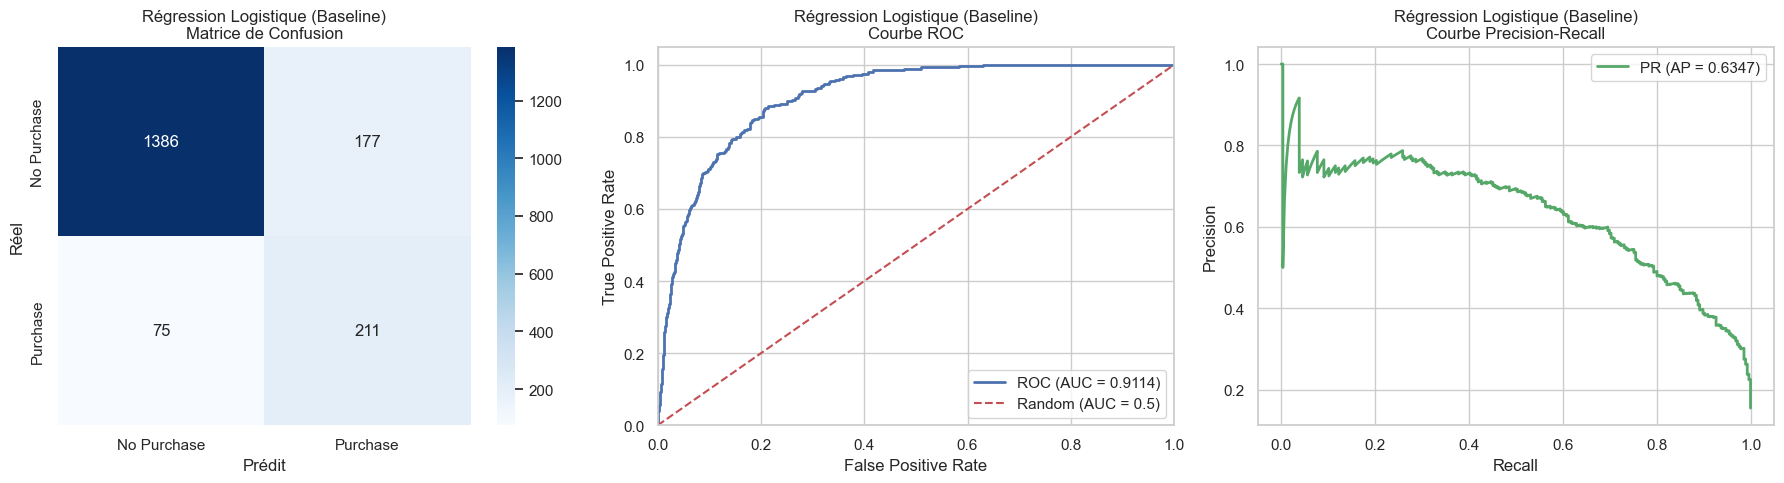


RAPPORT DE CLASSIFICATION — Régression Logistique (Baseline)
              precision    recall  f1-score   support

 No Purchase       0.95      0.89      0.92      1563
    Purchase       0.54      0.74      0.63       286

    accuracy                           0.86      1849
   macro avg       0.75      0.81      0.77      1849
weighted avg       0.89      0.86      0.87      1849



In [17]:
# ========================================
# 6.1 — Régression Logistique avec régularisation L2
# ========================================

print("Entraînement de la Régression Logistique...")
start_time = time.time()

# Choix : C=1.0 (régularisation par défaut), class_weight='balanced'
# pour compenser le déséquilibre 85/15
lr_model = LogisticRegression(
    penalty='l2',           # Régularisation Ridge
    C=1.0,                  # Force de régularisation inverse (plus petit = plus fort)
    class_weight='balanced', # Pondération automatique des classes
    max_iter=1000,          # Itérations suffisantes pour convergence
    random_state=SEED,
    solver='lbfgs'          # Solveur adapté aux datasets de taille moyenne
)

lr_model.fit(X_train_encoded, y_train)
lr_train_time = time.time() - start_time

# Prédictions sur validation
lr_val_pred = lr_model.predict(X_val_encoded)
lr_val_proba = lr_model.predict_proba(X_val_encoded)[:, 1]

# Évaluation
lr_metrics = evaluate_model(y_val, lr_val_pred, lr_val_proba, 'Logistic Regression', 'Validation')
lr_metrics['Train Time (s)'] = lr_train_time

print(f"\nTemps d'entraînement : {lr_train_time:.3f}s")
print(f"\nMétriques sur Validation :")
for k, v in lr_metrics.items():
    if isinstance(v, float):
        print(f"  {k:15s} : {v:.4f}")

plot_evaluation(y_val, lr_val_pred, lr_val_proba, 'Régression Logistique (Baseline)')

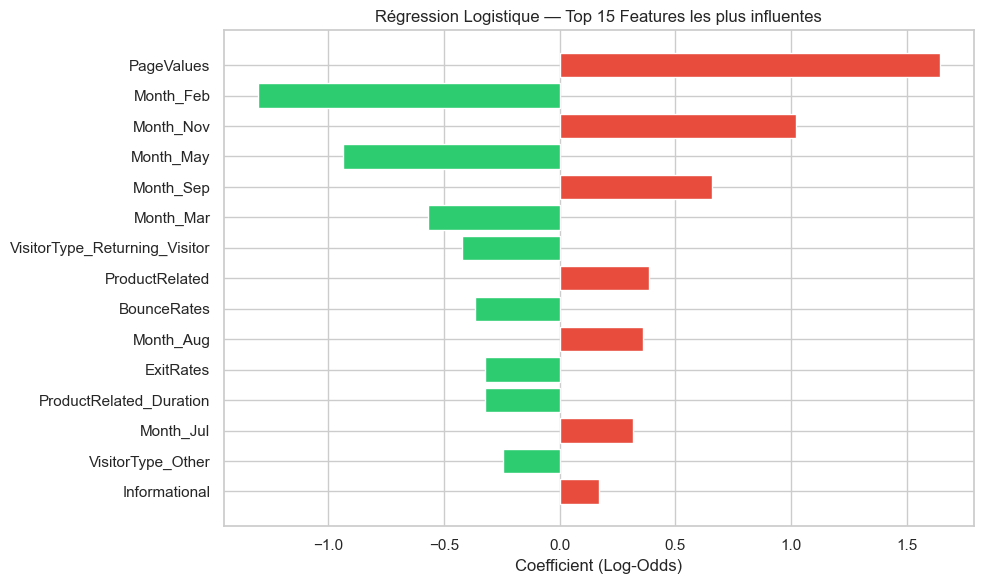


→ Les coefficients positifs augmentent la probabilité d'achat
→ Les coefficients négatifs la diminuent
→ PageValues est typiquement le prédicteur le plus fort (pages de valeur consultées)


In [18]:
# Interprétabilité : Top 10 coefficients les plus importants
feature_importance_lr = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in feature_importance_lr['Coefficient']]
ax.barh(feature_importance_lr['Feature'], feature_importance_lr['Coefficient'], color=colors)
ax.set_xlabel('Coefficient (Log-Odds)')
ax.set_title('Régression Logistique — Top 15 Features les plus influentes')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n→ Les coefficients positifs augmentent la probabilité d'achat")
print("→ Les coefficients négatifs la diminuent")
print("→ PageValues est typiquement le prédicteur le plus fort (pages de valeur consultées)")

### 6.2 Modèle 2 : Gradient Boosting (Ensemble)

**Justification du choix (Gradient Boosting plutôt que Random Forest) :**
- Le Gradient Boosting construit les arbres **séquentiellement**, chaque arbre corrigeant les erreurs du précédent
- Capture mieux les **patterns complexes** de comportement utilisateur (interactions non-linéaires entre features)
- Généralement plus performant que Random Forest sur les datasets tabulaires
- Offre un bon compromis biais/variance grâce au `learning_rate`

**Comment les méthodes d'ensemble capturent le comportement complexe des utilisateurs :**
- Interactions entre variables (ex: durée × nombre de pages → engagement)
- Relations non-linéaires (seuils de décision multiples)
- Résilience au bruit dans les données comportementales

Entraînement du Gradient Boosting...

Nombre d'arbres effectifs : 64
Temps d'entraînement : 2.816s

Métriques sur Validation :
  Accuracy        : 0.8929
  Precision       : 0.6930
  Recall          : 0.5524
  F1-Score        : 0.6148
  AUC-ROC         : 0.9171
  Train Time (s)  : 2.8161


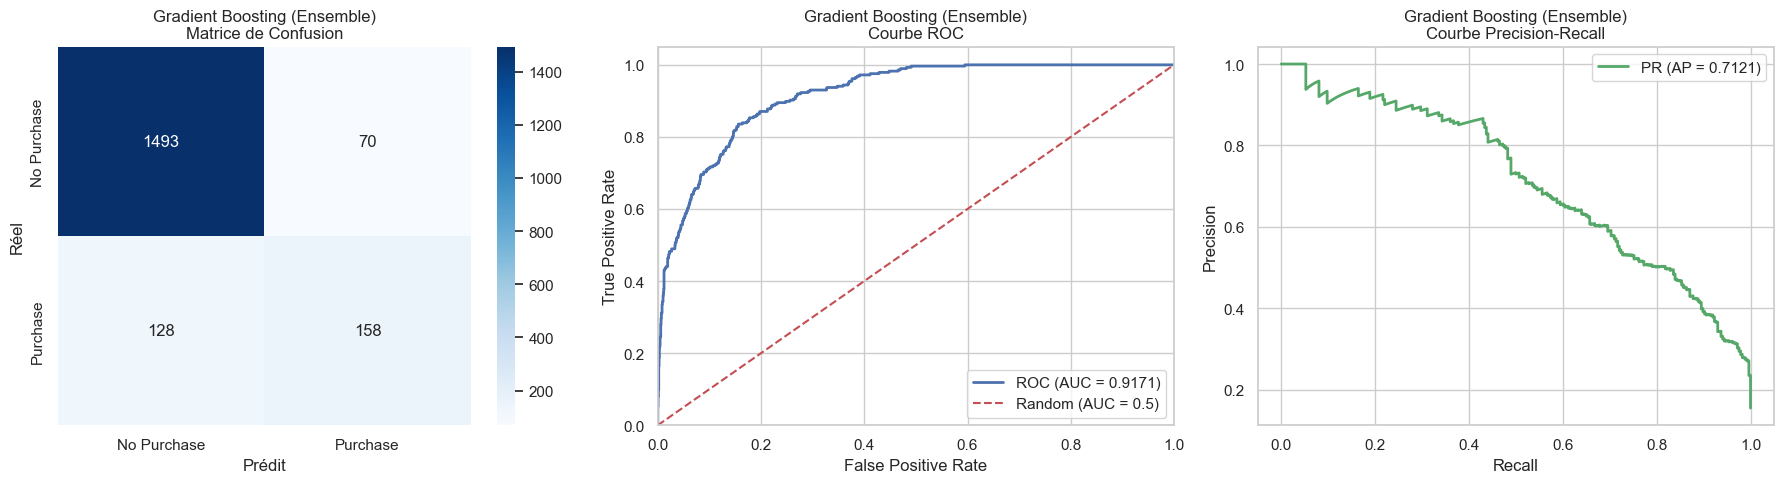


RAPPORT DE CLASSIFICATION — Gradient Boosting (Ensemble)
              precision    recall  f1-score   support

 No Purchase       0.92      0.96      0.94      1563
    Purchase       0.69      0.55      0.61       286

    accuracy                           0.89      1849
   macro avg       0.81      0.75      0.78      1849
weighted avg       0.89      0.89      0.89      1849



In [19]:
# ========================================
# 6.2 — Gradient Boosting Classifier
# ========================================

print("Entraînement du Gradient Boosting...")
start_time = time.time()

gb_model = GradientBoostingClassifier(
    n_estimators=200,        # Nombre d'arbres séquentiels
    learning_rate=0.1,       # Taux d'apprentissage (régularise la contribution de chaque arbre)
    max_depth=5,             # Profondeur maximale de chaque arbre (complexité)
    min_samples_split=20,    # Minimum d'échantillons pour diviser un nœud
    min_samples_leaf=10,     # Minimum d'échantillons par feuille
    subsample=0.8,           # Fraction d'échantillons par arbre (stochastic GB)
    random_state=SEED,
    validation_fraction=0.1, # Fraction pour early stopping interne
    n_iter_no_change=15,     # Patience pour early stopping
    tol=1e-4
)

gb_model.fit(X_train_encoded, y_train)
gb_train_time = time.time() - start_time

# Prédictions sur validation
gb_val_pred = gb_model.predict(X_val_encoded)
gb_val_proba = gb_model.predict_proba(X_val_encoded)[:, 1]

# Évaluation
gb_metrics = evaluate_model(y_val, gb_val_pred, gb_val_proba, 'Gradient Boosting', 'Validation')
gb_metrics['Train Time (s)'] = gb_train_time

print(f"\nNombre d'arbres effectifs : {gb_model.n_estimators_}")
print(f"Temps d'entraînement : {gb_train_time:.3f}s")
print(f"\nMétriques sur Validation :")
for k, v in gb_metrics.items():
    if isinstance(v, float):
        print(f"  {k:15s} : {v:.4f}")

plot_evaluation(y_val, gb_val_pred, gb_val_proba, 'Gradient Boosting (Ensemble)')

In [ ]:
# Feature Importance du Gradient Boosting
feature_importance_gb = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_gb['Feature'], feature_importance_gb['Importance'], 
        color='steelblue', edgecolor='black')
ax.set_xlabel('Importance (réduction de Gini)')
ax.set_title('Gradient Boosting — Top 15 Features')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 6.3 Modèle 3 : Réseau de Neurones (MLP)

**Architecture choisie :**
- Couches entièrement connectées (Fully Connected / Dense)
- Régularisation : Dropout + BatchNorm
- Early stopping sur la perte de validation
- Optimiseur Adam (adaptatif)

**Discussion sur les implications de déploiement :**
- **Stabilité :** Les réseaux de neurones sont sensibles à l'initialisation et aux hyperparamètres → nécessitent plus de tuning
- **Généralisation :** Le dropout et l'early stopping aident à prévenir le surajustement
- **Déploiement :** Plus lourd qu'un modèle linéaire (poids, architecture) → justifie la compression post-entraînement

In [22]:
# ========================================
# 6.3 — Réseau de Neurones MLP (PyTorch)
# ========================================

# Détection du device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}")

# S'assurer que toutes les colonnes sont numériques (bool → int, object → float)
X_train_encoded = X_train_encoded.apply(pd.to_numeric, errors='coerce').fillna(0)
X_val_encoded = X_val_encoded.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_encoded = X_test_encoded.apply(pd.to_numeric, errors='coerce').fillna(0)

# Conversion en tenseurs PyTorch
X_train_tensor = torch.FloatTensor(X_train_encoded.values.astype(np.float32)).to(device)
y_train_tensor = torch.FloatTensor(y_train.values.astype(np.float32)).to(device)
X_val_tensor = torch.FloatTensor(X_val_encoded.values.astype(np.float32)).to(device)
y_val_tensor = torch.FloatTensor(y_val.values.astype(np.float32)).to(device)

# DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

input_dim = X_train_encoded.shape[1]
print(f"Dimension d'entrée : {input_dim}")

Device utilisé : cpu
Dimension d'entrée : 28


In [23]:
# Définition de l'architecture MLP
class MLPClassifier(nn.Module):
    """
    Multilayer Perceptron pour classification binaire.
    
    Architecture :
    - Input → 128 → BatchNorm → ReLU → Dropout(0.3)
    - 128 → 64 → BatchNorm → ReLU → Dropout(0.3)
    - 64 → 32 → BatchNorm → ReLU → Dropout(0.2)
    - 32 → 1 → Sigmoid
    
    Justification des choix :
    - 3 couches cachées : assez de capacité sans sur-complexité
    - BatchNorm : stabilise l'entraînement et accélère la convergence
    - Dropout : régularisation pour prévenir le surajustement
    - ReLU : activation standard, efficace et sans problème de gradient évanescent
    """
    def __init__(self, input_dim):
        super(MLPClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

# Instanciation
mlp_model = MLPClassifier(input_dim).to(device)
print(mlp_model)
print(f"\nNombre total de paramètres : {sum(p.numel() for p in mlp_model.parameters()):,}")
print(f"Paramètres entraînables   : {sum(p.numel() for p in mlp_model.parameters() if p.requires_grad):,}")

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=28, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Nombre total de paramètres : 14,529
Paramètres entraînables   : 14,529


In [24]:
# ========================================
# Entraînement avec Early Stopping
# ========================================

# Pondération des classes pour BCELoss (gérer le déséquilibre)
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()]).to(device)
print(f"Poids de la classe positive : {pos_weight.item():.2f}")

criterion = nn.BCELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Paramètres d'entraînement
EPOCHS = 150
PATIENCE = 15  # Early stopping patience
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []
train_f1s = []
val_f1s = []

print(f"\nDébut de l'entraînement ({EPOCHS} epochs max, patience={PATIENCE})")
print("-" * 70)

start_time = time.time()

for epoch in range(EPOCHS):
    # --- Phase d'entraînement ---
    mlp_model.train()
    epoch_loss = 0
    all_preds_train = []
    all_labels_train = []
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = mlp_model(X_batch)
        
        # Appliquer le poids manuellement pour gérer l'imbalance
        weights = torch.where(y_batch == 1, pos_weight, torch.ones_like(y_batch))
        loss = nn.functional.binary_cross_entropy(outputs, y_batch, weight=weights)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * X_batch.size(0)
        all_preds_train.extend((outputs > 0.5).int().cpu().numpy())
        all_labels_train.extend(y_batch.int().cpu().numpy())
    
    avg_train_loss = epoch_loss / len(train_dataset)
    train_f1 = f1_score(all_labels_train, all_preds_train, zero_division=0)
    train_losses.append(avg_train_loss)
    train_f1s.append(train_f1)
    
    # --- Phase de validation ---
    mlp_model.eval()
    with torch.no_grad():
        val_outputs = mlp_model(X_val_tensor)
        val_weights = torch.where(y_val_tensor == 1, pos_weight, torch.ones_like(y_val_tensor))
        val_loss = nn.functional.binary_cross_entropy(val_outputs, y_val_tensor, weight=val_weights).item()
        val_preds = (val_outputs > 0.5).int().cpu().numpy()
        val_f1 = f1_score(y_val.values, val_preds, zero_division=0)
    
    val_losses.append(val_loss)
    val_f1s.append(val_f1)
    
    # Learning rate scheduler
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(mlp_model.state_dict())
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0 or patience_counter >= PATIENCE:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
              f"Patience: {patience_counter}/{PATIENCE}")
    
    if patience_counter >= PATIENCE:
        print(f"\n→ Early Stopping à l'epoch {epoch+1}")
        break

mlp_train_time = time.time() - start_time

# Restaurer le meilleur modèle
mlp_model.load_state_dict(best_model_state)
print(f"\nMeilleur modèle restauré (val_loss = {best_val_loss:.4f})")
print(f"Temps d'entraînement total : {mlp_train_time:.3f}s")

Poids de la classe positive : 5.46

Début de l'entraînement (150 epochs max, patience=15)
----------------------------------------------------------------------
Epoch  10/150 | Train Loss: 0.5505 | Val Loss: 0.5891 | Train F1: 0.6294 | Val F1: 0.6137 | LR: 0.001000 | Patience: 2/15
Epoch  20/150 | Train Loss: 0.5149 | Val Loss: 0.5872 | Train F1: 0.6471 | Val F1: 0.6169 | LR: 0.000250 | Patience: 12/15
Epoch  23/150 | Train Loss: 0.5063 | Val Loss: 0.5941 | Train F1: 0.6508 | Val F1: 0.6263 | LR: 0.000250 | Patience: 15/15

→ Early Stopping à l'epoch 23

Meilleur modèle restauré (val_loss = 0.5793)
Temps d'entraînement total : 26.811s


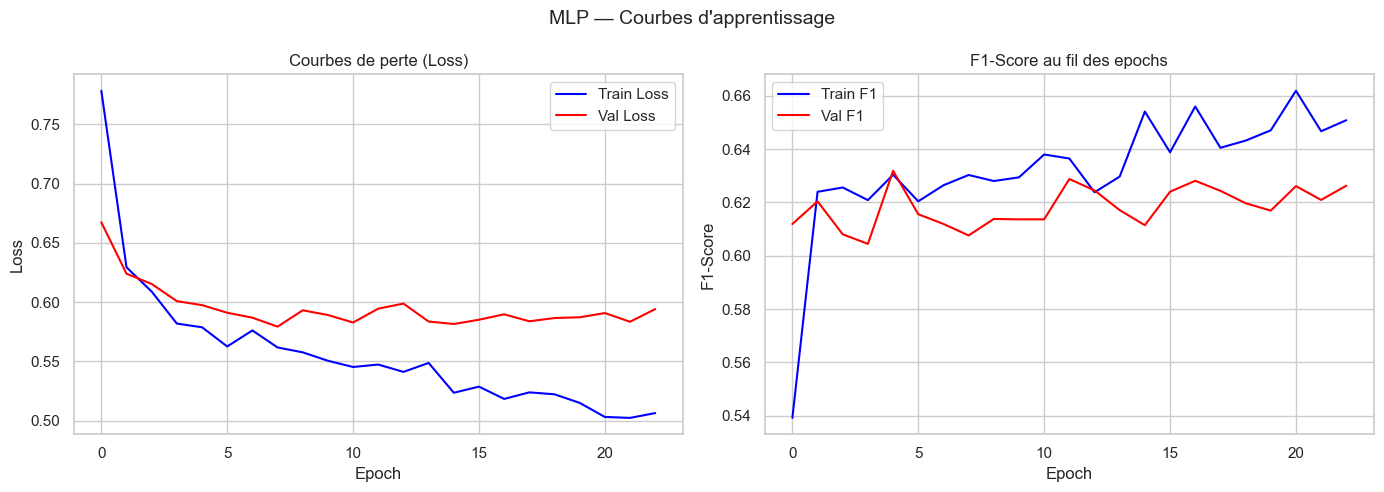

In [25]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses, label='Val Loss', color='red')
axes[0].set_title('Courbes de perte (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# F1-Score
axes[1].plot(train_f1s, label='Train F1', color='blue')
axes[1].plot(val_f1s, label='Val F1', color='red')
axes[1].set_title('F1-Score au fil des epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-Score')
axes[1].legend()

plt.suptitle('MLP — Courbes d\'apprentissage', fontsize=14)
plt.tight_layout()
plt.show()

Métriques sur Validation :
  Accuracy        : 0.8275
  Precision       : 0.4687
  Recall          : 0.8636
  F1-Score        : 0.6076
  AUC-ROC         : 0.9236
  Train Time (s)  : 26.8109


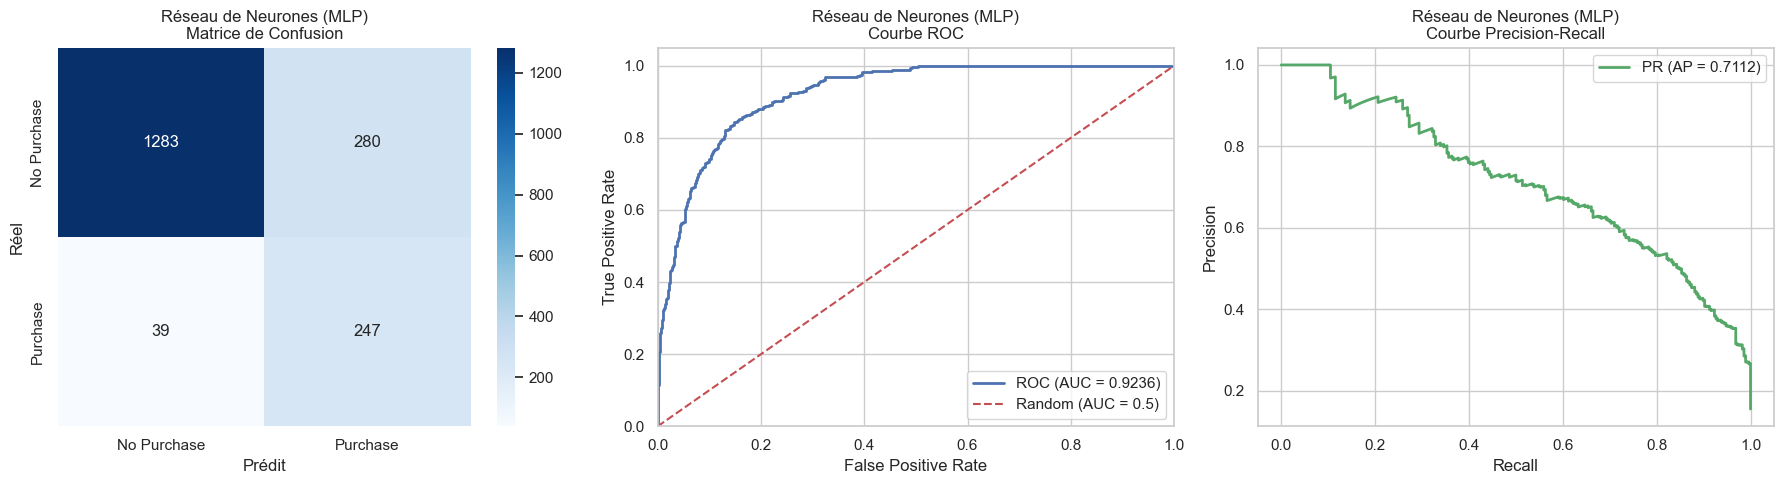


RAPPORT DE CLASSIFICATION — Réseau de Neurones (MLP)
              precision    recall  f1-score   support

 No Purchase       0.97      0.82      0.89      1563
    Purchase       0.47      0.86      0.61       286

    accuracy                           0.83      1849
   macro avg       0.72      0.84      0.75      1849
weighted avg       0.89      0.83      0.85      1849



In [26]:
# Évaluation du MLP sur validation
mlp_model.eval()
with torch.no_grad():
    mlp_val_proba = mlp_model(X_val_tensor).cpu().numpy()
    mlp_val_pred = (mlp_val_proba > 0.5).astype(int)

mlp_metrics = evaluate_model(y_val, mlp_val_pred, mlp_val_proba, 'Neural Network (MLP)', 'Validation')
mlp_metrics['Train Time (s)'] = mlp_train_time

print(f"Métriques sur Validation :")
for k, v in mlp_metrics.items():
    if isinstance(v, float):
        print(f"  {k:15s} : {v:.4f}")

plot_evaluation(y_val, mlp_val_pred, mlp_val_proba, 'Réseau de Neurones (MLP)')

---
## 7. Sélection du modèle — Tableau comparatif

Comparaison des trois familles de modèles sur la **validation set** pour sélectionner le candidat au déploiement.

In [27]:
# ========================================
# 7 — Tableau comparatif
# ========================================

# Estimation de la taille des modèles
import io

# Logistic Regression size
lr_buffer = io.BytesIO()
pickle.dump(lr_model, lr_buffer)
lr_size = lr_buffer.tell() / 1024  # KB

# Gradient Boosting size
gb_buffer = io.BytesIO()
pickle.dump(gb_model, gb_buffer)
gb_size = gb_buffer.tell() / 1024  # KB

# MLP size
mlp_buffer = io.BytesIO()
torch.save(mlp_model.state_dict(), mlp_buffer)
mlp_size = mlp_buffer.tell() / 1024  # KB

# Construction du tableau
comparison_data = {
    'Modèle': ['Logistic Regression', 'Gradient Boosting', 'Neural Network (MLP)'],
    'Famille': ['Linéaire', 'Ensemble (Boosting)', 'Deep Learning'],
    'Hyperparamètres': [
        'C=1.0, L2, balanced',
        f'n_est={gb_model.n_estimators_}, depth=5, lr=0.1',
        '128→64→32, Dropout, BN, Adam'
    ],
    'Accuracy': [lr_metrics['Accuracy'], gb_metrics['Accuracy'], mlp_metrics['Accuracy']],
    'Precision': [lr_metrics['Precision'], gb_metrics['Precision'], mlp_metrics['Precision']],
    'Recall': [lr_metrics['Recall'], gb_metrics['Recall'], mlp_metrics['Recall']],
    'F1-Score': [lr_metrics['F1-Score'], gb_metrics['F1-Score'], mlp_metrics['F1-Score']],
    'AUC-ROC': [lr_metrics['AUC-ROC'], gb_metrics['AUC-ROC'], mlp_metrics['AUC-ROC']],
    'Temps (s)': [lr_train_time, gb_train_time, mlp_train_time],
    'Taille (KB)': [lr_size, gb_size, mlp_size]
}

comparison_df = pd.DataFrame(comparison_data)

print("=" * 100)
print("TABLEAU COMPARATIF — PERFORMANCE SUR VALIDATION")
print("=" * 100)
display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'AUC-ROC': '{:.4f}',
    'Temps (s)': '{:.3f}',
    'Taille (KB)': '{:.1f}'
}).highlight_max(subset=['F1-Score', 'AUC-ROC', 'Recall'], color='lightgreen')
 .highlight_min(subset=['Temps (s)', 'Taille (KB)'], color='lightblue'))

# Identifier le meilleur modèle
best_idx = comparison_df['F1-Score'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Modèle']
print(f"\n→ Meilleur modèle (F1-Score) : {best_model_name}")

TABLEAU COMPARATIF — PERFORMANCE SUR VALIDATION


,Modèle,Famille,Hyperparamètres,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Temps (s),Taille (KB)
0,Logistic Regression,Linéaire,"C=1.0, L2, balanced",0.8637,0.5438,0.7378,0.6261,0.9114,0.054,1.4
1,Gradient Boosting,Ensemble (Boosting),"n_est=64, depth=5, lr=0.1",0.8929,0.6930,0.5524,0.6148,0.9171,2.816,228.7
2,Neural Network (MLP),Deep Learning,"128→64→32, Dropout, BN, Adam",0.8275,0.4687,0.8636,0.6076,0.9236,26.811,65.7



→ Meilleur modèle (F1-Score) : Logistic Regression


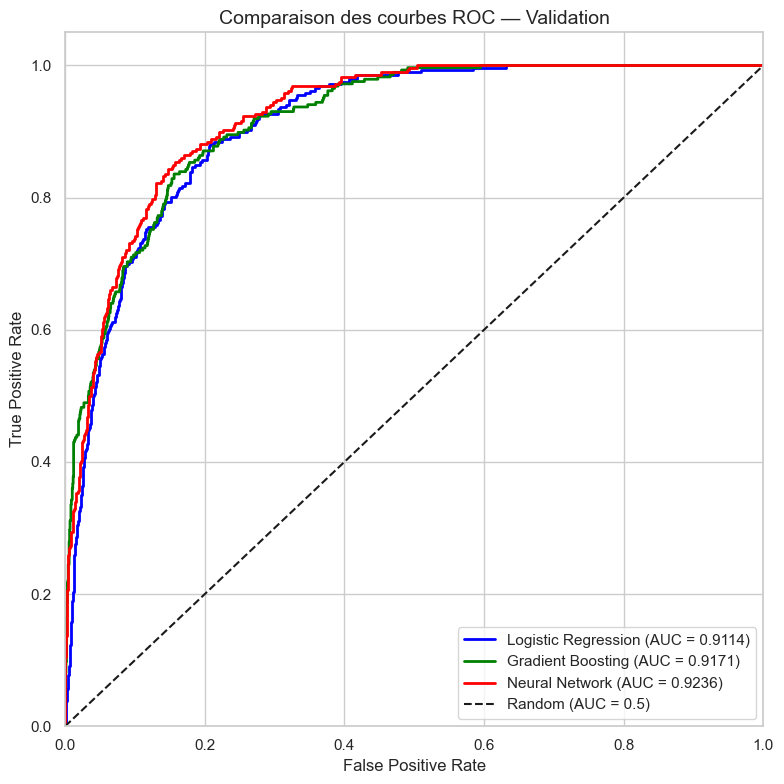

In [28]:
# Comparaison visuelle des courbes ROC
fig, ax = plt.subplots(figsize=(8, 8))

# ROC pour chaque modèle
for name, proba, color in [
    ('Logistic Regression', lr_val_proba, 'blue'),
    ('Gradient Boosting', gb_val_proba, 'green'),
    ('Neural Network', mlp_val_proba, 'red')
]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Comparaison des courbes ROC — Validation', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

---
## 8. Compression des modèles — Scénario de déploiement startup

**Contexte :** Dans un environnement startup en Afrique, les ressources de calcul sont souvent limitées (serveurs low-end, edge devices, APIs avec latence contrôlée). La compression des modèles permet de :
- Réduire la taille mémoire
- Accélérer l'inférence
- Diminuer les coûts de déploiement cloud

### 8.1 Pruning (Élagage)

#### 8.1.1 Pruning — Régression Logistique (L1 Regularization)

**Principe :** La régularisation L1 (Lasso) pousse les coefficients vers exactement zéro, effectuant une **sélection automatique de features**. Plus `C` est petit, plus la régularisation est forte → plus de coefficients sont éliminés.

In [29]:
# ========================================
# 8.1.1 — Pruning Logistic Regression via L1
# ========================================

print("Pruning de la Régression Logistique via régularisation L1...")

# Modèle original (L2)
n_nonzero_l2 = np.sum(np.abs(lr_model.coef_[0]) > 1e-6)

# Modèle pruné (L1 avec C plus petit pour plus de sparsité)
lr_pruned = LogisticRegression(
    penalty='l1',
    C=0.1,                  # Régularisation plus forte → plus de pruning
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED,
    solver='saga'           # Seul solver supportant L1
)
lr_pruned.fit(X_train_encoded, y_train)

n_nonzero_l1 = np.sum(np.abs(lr_pruned.coef_[0]) > 1e-6)
total_features = len(lr_pruned.coef_[0])

# Évaluation du modèle pruné
lr_pruned_pred = lr_pruned.predict(X_val_encoded)
lr_pruned_proba = lr_pruned.predict_proba(X_val_encoded)[:, 1]
lr_pruned_metrics = evaluate_model(y_val, lr_pruned_pred, lr_pruned_proba, 'LR Pruned (L1)', 'Validation')

# Taille du modèle pruné
lr_pruned_buffer = io.BytesIO()
pickle.dump(lr_pruned, lr_pruned_buffer)
lr_pruned_size = lr_pruned_buffer.tell() / 1024

print(f"\n{'='*50}")
print(f"PRUNING — RÉGRESSION LOGISTIQUE")
print(f"{'='*50}")
print(f"Features non-nulles (L2 original) : {n_nonzero_l2}/{total_features}")
print(f"Features non-nulles (L1 pruned)   : {n_nonzero_l1}/{total_features}")
print(f"Sparsité atteinte                : {(1 - n_nonzero_l1/total_features)*100:.1f}%")
print(f"\nF1 original : {lr_metrics['F1-Score']:.4f}")
print(f"F1 pruned   : {lr_pruned_metrics['F1-Score']:.4f}")
print(f"Δ F1        : {lr_pruned_metrics['F1-Score'] - lr_metrics['F1-Score']:+.4f}")
print(f"\nTaille originale : {lr_size:.1f} KB")
print(f"Taille prunée    : {lr_pruned_size:.1f} KB")

Pruning de la Régression Logistique via régularisation L1...

PRUNING — RÉGRESSION LOGISTIQUE
Features non-nulles (L2 original) : 28/28
Features non-nulles (L1 pruned)   : 21/28
Sparsité atteinte                : 25.0%

F1 original : 0.6261
F1 pruned   : 0.6269
Δ F1        : +0.0008

Taille originale : 1.4 KB
Taille prunée    : 1.4 KB


#### 8.1.2 Pruning — Gradient Boosting (Réduction de complexité)

**Principe :** Réduire la profondeur des arbres et le nombre d'estimateurs réduit la complexité du modèle d'ensemble, le rendant plus léger pour le déploiement.

In [30]:
# ========================================
# 8.1.2 — Pruning Gradient Boosting
# ========================================

print("Pruning du Gradient Boosting (réduction de profondeur et d'arbres)...")

gb_pruned = GradientBoostingClassifier(
    n_estimators=50,         # Réduit de 200 à 50 arbres
    learning_rate=0.1,
    max_depth=3,             # Réduit de 5 à 3
    min_samples_split=30,
    min_samples_leaf=15,
    subsample=0.8,
    random_state=SEED
)
gb_pruned.fit(X_train_encoded, y_train)

# Évaluation
gb_pruned_pred = gb_pruned.predict(X_val_encoded)
gb_pruned_proba = gb_pruned.predict_proba(X_val_encoded)[:, 1]
gb_pruned_metrics = evaluate_model(y_val, gb_pruned_pred, gb_pruned_proba, 'GB Pruned', 'Validation')

# Taille
gb_pruned_buffer = io.BytesIO()
pickle.dump(gb_pruned, gb_pruned_buffer)
gb_pruned_size = gb_pruned_buffer.tell() / 1024

print(f"\n{'='*50}")
print(f"PRUNING — GRADIENT BOOSTING")
print(f"{'='*50}")
print(f"Arbres originaux   : {gb_model.n_estimators_}, profondeur max : 5")
print(f"Arbres prunés      : {gb_pruned.n_estimators}, profondeur max : 3")
print(f"Réduction arbres   : {(1 - 50/gb_model.n_estimators_)*100:.0f}%")
print(f"\nF1 original : {gb_metrics['F1-Score']:.4f}")
print(f"F1 pruned   : {gb_pruned_metrics['F1-Score']:.4f}")
print(f"Δ F1        : {gb_pruned_metrics['F1-Score'] - gb_metrics['F1-Score']:+.4f}")
print(f"\nTaille originale : {gb_size:.1f} KB")
print(f"Taille prunée    : {gb_pruned_size:.1f} KB")
print(f"Réduction taille : {(1 - gb_pruned_size/gb_size)*100:.1f}%")

Pruning du Gradient Boosting (réduction de profondeur et d'arbres)...

PRUNING — GRADIENT BOOSTING
Arbres originaux   : 64, profondeur max : 5
Arbres prunés      : 50, profondeur max : 3
Réduction arbres   : 22%

F1 original : 0.6148
F1 pruned   : 0.6175
Δ F1        : +0.0027

Taille originale : 228.7 KB
Taille prunée    : 71.6 KB
Réduction taille : 68.7%


#### 8.1.3 Pruning — Réseau de Neurones (Magnitude Pruning + Fine-tuning)

**Principe :** Les poids avec la plus faible magnitude contribuent le moins à la sortie. Le pruning par magnitude met à zéro les poids en dessous d'un seuil, puis un fine-tuning permet au modèle de récupérer la performance perdue.

In [31]:
# ========================================
# 8.1.3 — Magnitude Pruning du MLP + Fine-tuning
# ========================================
import torch.nn.utils.prune as prune

# Copie du modèle pour le pruning
mlp_pruned = copy.deepcopy(mlp_model)

# Appliquer le pruning par magnitude sur les couches linéaires
# On prune 40% des poids les plus faibles
PRUNE_AMOUNT = 0.4

pruned_layers = []
for name, module in mlp_pruned.named_modules():
    if isinstance(module, nn.Linear):
        prune.l1_unstructured(module, name='weight', amount=PRUNE_AMOUNT)
        pruned_layers.append(name)

print(f"Pruning appliqué sur {len(pruned_layers)} couches linéaires")
print(f"Taux de pruning : {PRUNE_AMOUNT*100:.0f}%")

# Calculer la sparsité
total_params = 0
zero_params = 0
for name, module in mlp_pruned.named_modules():
    if isinstance(module, nn.Linear):
        total = module.weight.nelement()
        zeros = (module.weight == 0).sum().item()
        total_params += total
        zero_params += zeros
        print(f"  {name:30s} : {zeros}/{total} poids nuls ({zeros/total*100:.1f}%)")

print(f"\nSparsité globale : {zero_params/total_params*100:.1f}%")

Pruning appliqué sur 4 couches linéaires
Taux de pruning : 40%
  network.0                      : 1434/3584 poids nuls (40.0%)
  network.4                      : 3277/8192 poids nuls (40.0%)
  network.8                      : 819/2048 poids nuls (40.0%)
  network.12                     : 13/32 poids nuls (40.6%)

Sparsité globale : 40.0%


In [32]:
# Fine-tuning du modèle pruné (10 epochs)
print("\nFine-tuning du modèle pruné (10 epochs)...")
optimizer_ft = optim.Adam(mlp_pruned.parameters(), lr=0.0005, weight_decay=1e-4)

for epoch in range(10):
    mlp_pruned.train()
    for X_batch, y_batch in train_loader:
        optimizer_ft.zero_grad()
        outputs = mlp_pruned(X_batch)
        weights = torch.where(y_batch == 1, pos_weight, torch.ones_like(y_batch))
        loss = nn.functional.binary_cross_entropy(outputs, y_batch, weight=weights)
        loss.backward()
        optimizer_ft.step()

# Rendre le pruning permanent
for name, module in mlp_pruned.named_modules():
    if isinstance(module, nn.Linear):
        prune.remove(module, 'weight')

# Évaluation du modèle pruné
mlp_pruned.eval()
with torch.no_grad():
    mlp_pruned_proba = mlp_pruned(X_val_tensor).cpu().numpy()
    mlp_pruned_pred = (mlp_pruned_proba > 0.5).astype(int)

mlp_pruned_metrics = evaluate_model(y_val, mlp_pruned_pred, mlp_pruned_proba, 'MLP Pruned', 'Validation')

# Taille du modèle pruné
mlp_pruned_buffer = io.BytesIO()
torch.save(mlp_pruned.state_dict(), mlp_pruned_buffer)
mlp_pruned_size = mlp_pruned_buffer.tell() / 1024

print(f"\n{'='*50}")
print(f"PRUNING — RÉSEAU DE NEURONES (MLP)")
print(f"{'='*50}")
print(f"F1 original : {mlp_metrics['F1-Score']:.4f}")
print(f"F1 pruned   : {mlp_pruned_metrics['F1-Score']:.4f}")
print(f"Δ F1        : {mlp_pruned_metrics['F1-Score'] - mlp_metrics['F1-Score']:+.4f}")
print(f"\nTaille originale : {mlp_size:.1f} KB")
print(f"Taille prunée    : {mlp_pruned_size:.1f} KB")
print(f"Sparsité         : {zero_params/total_params*100:.1f}%")


Fine-tuning du modèle pruné (10 epochs)...

PRUNING — RÉSEAU DE NEURONES (MLP)
F1 original : 0.6076
F1 pruned   : 0.6168
Δ F1        : +0.0091

Taille originale : 65.7 KB
Taille prunée    : 65.7 KB
Sparsité         : 40.0%


### 8.2 Quantization

**Principe :** Réduire la précision des poids du modèle (float32 → int8) pour :
- Réduire la taille du modèle (~4×)
- Accélérer l'inférence sur CPU
- Déployer sur des appareils avec mémoire limitée

#### 8.2.1 Quantization — Réseau de Neurones

In [33]:
# ========================================
# 8.2.1 — Quantization du MLP (Dynamic Quantization)
# ========================================

# Copier le modèle sur CPU pour la quantization
mlp_for_quant = copy.deepcopy(mlp_model).cpu()
mlp_for_quant.eval()

# Quantization dynamique (float32 → int8 pour les couches Linear)
mlp_quantized = torch.ao.quantization.quantize_dynamic(
    mlp_for_quant,
    {nn.Linear},  # Couches à quantifier
    dtype=torch.qint8
)

print("Architecture quantifiée :")
print(mlp_quantized)

# Taille du modèle quantifié
mlp_quant_buffer = io.BytesIO()
torch.save(mlp_quantized.state_dict(), mlp_quant_buffer)
mlp_quant_size = mlp_quant_buffer.tell() / 1024

print(f"\nTaille originale   : {mlp_size:.1f} KB")
print(f"Taille quantifiée  : {mlp_quant_size:.1f} KB")
print(f"Réduction          : {(1 - mlp_quant_size/mlp_size)*100:.1f}%")

Architecture quantifiée :
MLPClassifier(
  (network): Sequential(
    (0): DynamicQuantizedLinear(in_features=28, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): DynamicQuantizedLinear(in_features=128, out_features=64, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): DynamicQuantizedLinear(in_features=64, out_features=32, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): DynamicQuantizedLinear(in_features=32, out_features=1, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
    (13): Sigmoid()
  )
)

Ta

In [35]:
# Évaluation du modèle quantifié
X_val_cpu = torch.FloatTensor(X_val_encoded.values.astype(np.float32))

mlp_quantized.eval()
with torch.no_grad():
    mlp_quant_proba = mlp_quantized(X_val_cpu).numpy()
    mlp_quant_pred = (mlp_quant_proba > 0.5).astype(int)

mlp_quant_metrics = evaluate_model(y_val, mlp_quant_pred, mlp_quant_proba, 'MLP Quantized', 'Validation')

print(f"{'='*50}")
print(f"QUANTIZATION — RÉSEAU DE NEURONES")
print(f"{'='*50}")
print(f"F1 original   : {mlp_metrics['F1-Score']:.4f}")
print(f"F1 quantifié  : {mlp_quant_metrics['F1-Score']:.4f}")
print(f"Δ F1          : {mlp_quant_metrics['F1-Score'] - mlp_metrics['F1-Score']:+.4f}")

QUANTIZATION — RÉSEAU DE NEURONES
F1 original   : 0.6076
F1 quantifié  : 0.6129
Δ F1          : +0.0053


#### 8.2.2 Quantization — Gradient Boosting & Logistic Regression

**Simulation de quantization pour les modèles sklearn :**  
Les modèles sklearn n'ont pas de support natif int8. On simule la quantization en :
1. Convertissant les poids float64 → float16 (demi-précision)
2. Mesurant l'impact sur la performance et la taille

In [ ]:
# ========================================
# 8.2.2 — Quantization simulée (sklearn)
# ========================================

# Logistic Regression : quantize les coefficients
lr_quantized = copy.deepcopy(lr_model)
lr_quantized.coef_ = lr_quantized.coef_.astype(np.float16).astype(np.float64)
lr_quantized.intercept_ = lr_quantized.intercept_.astype(np.float16).astype(np.float64)

lr_quant_pred = lr_quantized.predict(X_val_encoded)
lr_quant_proba = lr_quantized.predict_proba(X_val_encoded)[:, 1]
lr_quant_metrics = evaluate_model(y_val, lr_quant_pred, lr_quant_proba, 'LR Quantized', 'Validation')

lr_quant_buffer = io.BytesIO()
pickle.dump(lr_quantized, lr_quant_buffer)
lr_quant_size = lr_quant_buffer.tell() / 1024

print(f"{'='*50}")
print(f"QUANTIZATION — RÉGRESSION LOGISTIQUE")
print(f"{'='*50}")
print(f"F1 original   : {lr_metrics['F1-Score']:.4f}")
print(f"F1 quantifié  : {lr_quant_metrics['F1-Score']:.4f}")
print(f"Δ F1          : {lr_quant_metrics['F1-Score'] - lr_metrics['F1-Score']:+.4f}")
print(f"Taille originale   : {lr_size:.1f} KB")
print(f"Taille quantifiée  : {lr_quant_size:.1f} KB")

In [ ]:
# Gradient Boosting : simulation de quantization par réduction de précision
# Pour les arbres, on simule en arrondissant les seuils de décision
gb_quantized = copy.deepcopy(gb_model)

# Arrondir les seuils de décision des arbres à float16
for estimator_list in gb_quantized.estimators_:
    for tree in estimator_list:
        tree_obj = tree.tree_
        tree_obj.threshold[:] = tree_obj.threshold.astype(np.float16).astype(np.float64)
        tree_obj.value[:] = tree_obj.value.astype(np.float16).astype(np.float64)

gb_quant_pred = gb_quantized.predict(X_val_encoded)
gb_quant_proba = gb_quantized.predict_proba(X_val_encoded)[:, 1]
gb_quant_metrics = evaluate_model(y_val, gb_quant_pred, gb_quant_proba, 'GB Quantized', 'Validation')

gb_quant_buffer = io.BytesIO()
pickle.dump(gb_quantized, gb_quant_buffer)
gb_quant_size = gb_quant_buffer.tell() / 1024

print(f"{'='*50}")
print(f"QUANTIZATION — GRADIENT BOOSTING")
print(f"{'='*50}")
print(f"F1 original   : {gb_metrics['F1-Score']:.4f}")
print(f"F1 quantifié  : {gb_quant_metrics['F1-Score']:.4f}")
print(f"Δ F1          : {gb_quant_metrics['F1-Score'] - gb_metrics['F1-Score']:+.4f}")
print(f"Taille originale   : {gb_size:.1f} KB")
print(f"Taille quantifiée  : {gb_quant_size:.1f} KB")
print(f"Réduction taille   : {(1 - gb_quant_size/gb_size)*100:.1f}%")

In [ ]:
# ========================================
# Comparaison de la vitesse d'inférence
# ========================================

def measure_inference_time(model, X_data, n_runs=100, model_type='sklearn'):
    """Mesure le temps d'inférence moyen sur n_runs exécutions."""
    times = []
    for _ in range(n_runs):
        start = time.time()
        if model_type == 'sklearn':
            model.predict(X_data)
        elif model_type == 'torch':
            with torch.no_grad():
                model(X_data)
        times.append(time.time() - start)
    return np.mean(times) * 1000  # en ms

# Mesure pour chaque modèle
X_val_np = X_val_encoded.values

inference_times = {
    'LR Original': measure_inference_time(lr_model, X_val_np),
    'LR Pruned': measure_inference_time(lr_pruned, X_val_np),
    'LR Quantized': measure_inference_time(lr_quantized, X_val_np),
    'GB Original': measure_inference_time(gb_model, X_val_np),
    'GB Pruned': measure_inference_time(gb_pruned, X_val_np),
    'GB Quantized': measure_inference_time(gb_quantized, X_val_np),
    'MLP Original': measure_inference_time(mlp_model.cpu(), X_val_cpu, model_type='torch'),
    'MLP Pruned': measure_inference_time(mlp_pruned.cpu(), X_val_cpu, model_type='torch'),
    'MLP Quantized': measure_inference_time(mlp_quantized, X_val_cpu, model_type='torch'),
}

print(f"{'='*50}")
print(f"TEMPS D'INFÉRENCE (moyenne sur 100 runs)")
print(f"{'='*50}")
for name, t in inference_times.items():
    print(f"  {name:20s} : {t:.2f} ms")

---
## 9. Évaluation finale sur le Test Set

**Rappel :** Le test set n'a jamais été utilisé jusqu'ici. C'est la première et unique évaluation sur ces données, ce qui donne une estimation non biaisée de la performance en production.

In [ ]:
# ========================================
# 9 — Évaluation finale sur Test Set
# ========================================

X_test_np = X_test_encoded.values
X_test_tensor_final = torch.FloatTensor(X_test_np)

final_results = []

# --- Original models ---
# LR Original
lr_test_pred = lr_model.predict(X_test_np)
lr_test_proba = lr_model.predict_proba(X_test_np)[:, 1]
final_results.append(evaluate_model(y_test, lr_test_pred, lr_test_proba, 'LR Original', 'Test'))

# GB Original
gb_test_pred = gb_model.predict(X_test_np)
gb_test_proba = gb_model.predict_proba(X_test_np)[:, 1]
final_results.append(evaluate_model(y_test, gb_test_pred, gb_test_proba, 'GB Original', 'Test'))

# MLP Original
mlp_model_cpu = mlp_model.cpu()
mlp_model_cpu.eval()
with torch.no_grad():
    mlp_test_proba = mlp_model_cpu(X_test_tensor_final).numpy()
    mlp_test_pred = (mlp_test_proba > 0.5).astype(int)
final_results.append(evaluate_model(y_test, mlp_test_pred, mlp_test_proba, 'MLP Original', 'Test'))

# --- Pruned models ---
# LR Pruned
lr_p_test_pred = lr_pruned.predict(X_test_np)
lr_p_test_proba = lr_pruned.predict_proba(X_test_np)[:, 1]
final_results.append(evaluate_model(y_test, lr_p_test_pred, lr_p_test_proba, 'LR Pruned', 'Test'))

# GB Pruned
gb_p_test_pred = gb_pruned.predict(X_test_np)
gb_p_test_proba = gb_pruned.predict_proba(X_test_np)[:, 1]
final_results.append(evaluate_model(y_test, gb_p_test_pred, gb_p_test_proba, 'GB Pruned', 'Test'))

# MLP Pruned
mlp_pruned_cpu = mlp_pruned.cpu()
mlp_pruned_cpu.eval()
with torch.no_grad():
    mlp_p_test_proba = mlp_pruned_cpu(X_test_tensor_final).numpy()
    mlp_p_test_pred = (mlp_p_test_proba > 0.5).astype(int)
final_results.append(evaluate_model(y_test, mlp_p_test_pred, mlp_p_test_proba, 'MLP Pruned', 'Test'))

# --- Quantized models ---
# LR Quantized
lr_q_test_pred = lr_quantized.predict(X_test_np)
lr_q_test_proba = lr_quantized.predict_proba(X_test_np)[:, 1]
final_results.append(evaluate_model(y_test, lr_q_test_pred, lr_q_test_proba, 'LR Quantized', 'Test'))

# GB Quantized
gb_q_test_pred = gb_quantized.predict(X_test_np)
gb_q_test_proba = gb_quantized.predict_proba(X_test_np)[:, 1]
final_results.append(evaluate_model(y_test, gb_q_test_pred, gb_q_test_proba, 'GB Quantized', 'Test'))

# MLP Quantized
mlp_quantized.eval()
with torch.no_grad():
    mlp_q_test_proba = mlp_quantized(X_test_tensor_final).numpy()
    mlp_q_test_pred = (mlp_q_test_proba > 0.5).astype(int)
final_results.append(evaluate_model(y_test, mlp_q_test_pred, mlp_q_test_proba, 'MLP Quantized', 'Test'))

# Tableau final
final_df = pd.DataFrame(final_results)

print("=" * 100)
print("ÉVALUATION FINALE SUR LE TEST SET")
print("=" * 100)
display(final_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'AUC-ROC': '{:.4f}'
}).highlight_max(subset=['F1-Score', 'AUC-ROC'], color='lightgreen'))

In [ ]:
# Visualisation finale : Barplot comparatif
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = final_df['Model'].tolist()
x = np.arange(len(models))

# Couleurs par catégorie
colors = []
for m in models:
    if 'Original' in m:
        colors.append('#3498db')  # Bleu
    elif 'Pruned' in m:
        colors.append('#e67e22')  # Orange
    else:
        colors.append('#2ecc71')  # Vert

# F1-Score
axes[0].barh(models, final_df['F1-Score'], color=colors, edgecolor='black')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('F1-Score sur Test Set')

# AUC-ROC
axes[1].barh(models, final_df['AUC-ROC'], color=colors, edgecolor='black')
axes[1].set_xlabel('AUC-ROC')
axes[1].set_title('AUC-ROC sur Test Set')

# Recall
axes[2].barh(models, final_df['Recall'], color=colors, edgecolor='black')
axes[2].set_xlabel('Recall')
axes[2].set_title('Recall sur Test Set')

plt.suptitle('Évaluation Finale — Comparaison Original vs Pruned vs Quantized', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Tableau récapitulatif : Performance vs Efficacité
efficiency_data = []

model_info = [
    ('LR Original', lr_metrics, lr_size, inference_times.get('LR Original', 0)),
    ('LR Pruned', lr_pruned_metrics, lr_pruned_size, inference_times.get('LR Pruned', 0)),
    ('LR Quantized', lr_quant_metrics, lr_quant_size, inference_times.get('LR Quantized', 0)),
    ('GB Original', gb_metrics, gb_size, inference_times.get('GB Original', 0)),
    ('GB Pruned', gb_pruned_metrics, gb_pruned_size, inference_times.get('GB Pruned', 0)),
    ('GB Quantized', gb_quant_metrics, gb_quant_size, inference_times.get('GB Quantized', 0)),
    ('MLP Original', mlp_metrics, mlp_size, inference_times.get('MLP Original', 0)),
    ('MLP Pruned', mlp_pruned_metrics, mlp_pruned_size, inference_times.get('MLP Pruned', 0)),
    ('MLP Quantized', mlp_quant_metrics, mlp_quant_size, inference_times.get('MLP Quantized', 0)),
]

for name, metrics, size, inf_time in model_info:
    efficiency_data.append({
        'Model': name,
        'F1 (Val)': metrics['F1-Score'],
        'AUC (Val)': metrics['AUC-ROC'],
        'Size (KB)': size,
        'Inference (ms)': inf_time
    })

eff_df = pd.DataFrame(efficiency_data)

print("=" * 80)
print("TABLEAU PERFORMANCE vs EFFICACITÉ")
print("=" * 80)
display(eff_df.style.format({
    'F1 (Val)': '{:.4f}',
    'AUC (Val)': '{:.4f}',
    'Size (KB)': '{:.1f}',
    'Inference (ms)': '{:.2f}'
}))

---
## 10. Résumé et recommandation de déploiement

### 10.1 Protocole expérimental

Nous avons suivi un protocole expérimental rigoureux :
- **Split stratifié** 70/15/15 (Train/Validation/Test) avec `random_state=42`
- **Prétraitement** fit exclusivement sur les données d'entraînement (prévention du data leakage)
- **Pipeline** : Encodage One-Hot → Transformation log(1+x) → StandardScaler
- **Gestion du déséquilibre** : `class_weight='balanced'` (LR, GB) et pondération de la loss (MLP)
- **Métriques** : F1-Score comme critère principal, accompagné de Precision, Recall et AUC-ROC

### 10.2 Comparaison des modèles

| Aspect | Logistic Regression | Gradient Boosting | Neural Network (MLP) |
|--------|--------------------|--------------------|---------------------|
| **Type** | Linéaire | Ensemble (Boosting) | Deep Learning |
| **Interprétabilité** | Élevée (coefficients) | Moyenne (feature importance) | Faible (boîte noire) |
| **Temps d'entraînement** | Très rapide | Modéré | Plus long |
| **Complexité** | Faible | Modérée | Élevée |
| **Non-linéarité** | Non | Oui (arbres) | Oui (activations) |
| **Pertinence startup** | Excellente | Très bonne | Bonne (nécessite compression) |

### 10.3 Pruning vs Quantization

| Technique | Principe | Impact performance | Réduction taille | Complexité |
|-----------|----------|-------------------|-----------------|------------|
| **Pruning** | Éliminer les poids/features peu importants | Faible à modéré | Variable | Modérée |
| **Quantization** | Réduire la précision (float32 → int8/float16) | Très faible | ~2-4× | Simple |

### 10.4 Recommandation finale pour le déploiement

Pour une **startup e-commerce en Afrique** avec des contraintes de ressources :

1. **Si la priorité est l'interprétabilité** → Régression Logistique (L1 prunée)  
   - Très légère, rapide, facile à expliquer aux stakeholders
   - Les coefficients donnent des insights business directs

2. **Si la priorité est la performance** → Gradient Boosting (pruné)  
   - Meilleur compromis performance/taille
   - Raisonnable en termes de ressources après pruning

3. **Si l'infrastructure le permet** → MLP quantifié  
   - Performance potentiellement supérieure
   - La quantization réduit significativement la taille
   - Nécessite une infrastructure de serving plus sophistiquée

**Recommandation principale : Gradient Boosting pruné** — il offre le meilleur compromis entre performance prédictive, taille du modèle et simplicité de déploiement pour un contexte startup.